# GDELT 2.0 — Timeline Tone (stable version)

This notebook pulls the **average news tone timeline** (`timelinetone`) from the
GDELT 2.0 DOC API, filtered by region.

### Why the old notebook was unstable ("sometimes works, sometimes not")
GDELT throttles **per IP** at roughly **one request every 5 seconds**, and — this is the
important part — once you exceed it (especially with a *burst* of calls) it puts the IP in
an **extended penalty box** that can last *minutes*, replying with
`HTTP 429: "Please limit requests to one every 5 seconds…"`. The old code only slept
*between* the three high-level calls and gave up after 4 short retries, so any leftover
cooldown made the whole run fail. (Verified live: after a short burst, even a 65-second
wait still returned 429.)

### What this version does
1. A **global throttle** enforces a minimum gap *before every request* (not just between calls).
2. **Exponential backoff + random jitter** on 429, honouring any `Retry-After` header, with
   enough total wait to ride out the penalty box.
3. Robust handling of GDELT's quirks (200 responses that contain a plain-text error, empty
   bodies, and the mandatory browser `User-Agent`).

Sources: [DOC 2.0 API announcement](https://blog.gdeltproject.org/gdelt-doc-2-0-api-debuts/) ·
[API quotas / a fraction of a QPS](https://blog.gdeltproject.org/behind-the-scenes-api-quotas-the-impact-of-a-fraction-of-a-qps/) ·
[gdelt-doc-api issue #22 (User-Agent fix)](https://github.com/alex9smith/gdelt-doc-api/issues/22)

In [9]:
import os, time, random, threading
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# GDELT needs no key; we load .env only to stay consistent with the other notebooks.
load_ok = None
try:
    from dotenv import load_dotenv
    load_ok = load_dotenv(Path.cwd().parent / ".env")
except Exception as e:
    print("dotenv not loaded (not required for GDELT):", e)
load_ok

True

In [11]:
# ---------------------------------------------------------------------------
# Robust GDELT DOC 2.0 client
# ---------------------------------------------------------------------------
DOC_BASE = "https://api.gdeltproject.org/api/v2/doc/doc"

# A real browser User-Agent is MANDATORY — GDELT returns 429 to non-browser clients.
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/124.0 Safari/537.36"),
    "Accept": "application/json",
}

# >>> THE LAG KNOB YOU ASKED ABOUT <<<
# MIN_INTERVAL is the minimum gap enforced *before every request*, GLOBALLY and
# *across cells* (the timer lives in _LAST_CALL, which survives between cell runs).
# So two helper calls in a row (e.g. timeline_tone() then timeline_volume()) are
# already spaced by this value automatically — no manual time.sleep() needed.
# GDELT's floor is ~5 s; raise this if you still trip the limit on a clean IP.
MIN_INTERVAL = 10.0         # seconds enforced *before* every request (was 6)
_LAST_CALL = [0.0]
_LOCK = threading.Lock()


def _throttle():
    """Block until at least MIN_INTERVAL has passed since the previous request."""
    with _LOCK:
        gap = MIN_INTERVAL - (time.monotonic() - _LAST_CALL[0])
        if gap > 0:
            time.sleep(gap)
        _LAST_CALL[0] = time.monotonic()


def cooldown(minutes=15):
    """Sit idle (making NO requests) to let GDELT's per-IP penalty box expire.

    Run this cell when you keep getting 429s even on a single well-spaced call.
    Once GDELT has penalised your IP, *every* further request can prolong the
    block, so the only reliable cure is to stop calling GDELT entirely for a
    while and THEN make one request. Do not Ctrl+C a backoff and immediately
    rerun — that is what keeps you stuck.
    """
    print(f"Cooling down for {minutes} min with zero GDELT requests...")
    time.sleep(int(minutes * 60))
    _LAST_CALL[0] = 0.0  # reset throttle clock so the next call fires right away
    print("Cooldown done. Now run ONE timeline_tone() call and let it finish "
          "without interrupting it.")


def _get(params, base_url=DOC_BASE, max_retries=6, base_pause=12.0,
         max_pause=180.0, verbose=True):
    """GET a GDELT endpoint with throttling + exponential backoff and jitter.

    Handles GDELT's failure modes:
      * HTTP 429              -> rate-limited / penalty box  (retry with backoff)
      * 200 + plain-text body -> bad query or transient error
      * 200 + empty body      -> transient                  (retry)
    Raises RuntimeError with a clear message if it never succeeds.

    NOTE on 429s: GDELT can drop an IP into an *extended* penalty box (minutes)
    after a burst, and hitting it again while penalised can prolong it. The
    backoff therefore grows quickly and waits up to `max_pause` seconds between
    attempts so the penalty has time to clear rather than being repoked. Worst
    case here is ~9 min (12+24+48+96+180+180s) before giving up with a clear
    message. If you hit that wall, run cooldown() and try again later — and note
    that on a SHARED IP (corporate/uni network) the limit is consumed by everyone
    on that network, so client-side pacing alone may not be enough.
    """
    last_err = None
    for attempt in range(max_retries):
        _throttle()
        try:
            r = requests.get(base_url, params=params, headers=HEADERS, timeout=30)
        except requests.RequestException as e:
            last_err = e
            if verbose:
                print(f"  network error: {e} (attempt {attempt + 1}/{max_retries})")
            time.sleep(base_pause)
            continue

        if r.status_code == 429:
            ra = r.headers.get("Retry-After")
            if ra and ra.isdigit():
                pause = float(ra)
            else:
                pause = base_pause * (2 ** attempt)              # exponential
            pause = min(pause, max_pause) + random.uniform(0, base_pause)  # + jitter
            last_err = RuntimeError("HTTP 429 rate-limited")
            if verbose:
                print(f"  429 rate-limited; backing off {pause:.0f}s "
                      f"(attempt {attempt + 1}/{max_retries})  "
                      f"[do NOT interrupt + rerun — that prolongs the block]")
            time.sleep(pause)
            continue

        r.raise_for_status()
        ctype = r.headers.get("content-type", "")
        if "json" not in ctype:
            body = r.text.strip()
            if not body:                       # empty -> transient, retry
                last_err = RuntimeError("empty response body")
                if verbose:
                    print(f"  empty body; retrying (attempt {attempt + 1}/{max_retries})")
                time.sleep(base_pause)
                continue
            # non-empty, non-JSON -> a genuine query error; don't waste retries
            raise RuntimeError(f"GDELT rejected the query: {body[:200]}")
        return r.json()

    raise RuntimeError(
        f"GDELT still unavailable after {max_retries} attempts ({last_err}). "
        "Your IP is in GDELT's penalty box. Run cooldown(), wait, then rerun ONE "
        "cell. On a shared/corporate IP, consider BigQuery (gdelt-bq) instead."
    )

In [12]:
# ---------------------------------------------------------------------------
# Query builder + timeline helpers
# ---------------------------------------------------------------------------
def build_query(phrase=None, keyword=None, sourcecountry=None, sourcelang=None,
                theme=None, domain=None, extra=None):
    """Assemble a GDELT DOC query string from common filters.

    Region filter:
      * sourcecountry -> country the *outlet* is based in (FIPS code or name),
        e.g. "UK", "US", or "unitedkingdom". This is the DOC API's real
        geographic filter.

    NOTE: GDELT requires at least one actual search term (a phrase/keyword);
    a query made of only operators (e.g. just `sourcecountry:UK`) is rejected.
    """
    parts = []
    if phrase:
        parts.append(f'"{phrase}"')
    if keyword:
        parts.append(keyword)
    if sourcecountry:
        parts.append(f"sourcecountry:{sourcecountry}")
    if sourcelang:
        parts.append(f"sourcelang:{sourcelang}")
    if theme:
        parts.append(f"theme:{theme}")
    if domain:
        parts.append(f"domain:{domain}")
    if extra:
        parts.append(extra)
    if not (phrase or keyword):
        raise ValueError("GDELT needs at least a phrase or keyword, not only filters.")
    return " ".join(parts).strip()


def timeline_tone(query, timespan="14d", smooth=None, **extra):
    """Average-tone timeline for articles matching `query`.

    Tone runs ~ -100..+100 (most values -10..+10): negative = unfavourable
    coverage, 0 = neutral, positive = favourable. Returns DataFrame [date, tone].
    `smooth` (int) applies GDELT's moving-average smoothing over N points.
    """
    params = {"query": query, "mode": "timelinetone",
              "format": "json", "timespan": timespan, **extra}
    if smooth:
        params["timelinesmooth"] = int(smooth)
    data = _get(params)
    tl = data.get("timeline", [])
    series = tl[0].get("data", []) if tl else []
    df = pd.json_normalize(series)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df = df.rename(columns={"value": "tone"})[["date", "tone"]]
    return df


def timeline_volume(query, timespan="14d", **extra):
    """Daily volume-of-coverage timeline. Returns DataFrame [date, value]."""
    params = {"query": query, "mode": "timelinevol",
              "format": "json", "timespan": timespan, **extra}
    data = _get(params)
    tl = data.get("timeline", [])
    series = tl[0].get("data", []) if tl else []
    df = pd.json_normalize(series)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
    return df


def article_search(query, timespan="7d", maxrecords=25, **extra):
    """Matching articles as a DataFrame (seendate, title, domain, url, ...)."""
    params = {"query": query, "mode": "artlist", "format": "json",
              "timespan": timespan, "maxrecords": maxrecords, **extra}
    data = _get(params)
    return pd.json_normalize(data.get("articles", []))

## Filtering by region — two different meanings

"Region" can mean two different things in GDELT; don't confuse them:

**1. Source region — where the article is PUBLISHED — `sourcecountry`.**
Supported directly by the DOC API (FIPS 10-4 code or lowercased name):

| Country | code |  | Country | code |
|---|---|---|---|---|
| United Kingdom | `UK` |  | Japan | `JA` |
| United States | `US` |  | Germany | `GM` |
| France | `FR` |  | China | `CH` |
| Australia | `AS` |  | India | `IN` |

(Full list in the [DOC 2.0 API docs](https://blog.gdeltproject.org/gdelt-doc-2-0-api-debuts/).)
The `timeline_tone` example above uses this — exact-keyword tone for UK-published coverage.

**2. Subject region — the place the story is ABOUT — e.g. London, Bristol, the North East.**
The DOC API has **no `V2Locations` operator** and can't truly geolocate a story, so subject-region
analysis lives in the **BigQuery section** below: **Query B** reads the GKG `V2Locations` / `V2Tone`
fields directly to rank UK regions by *real* geolocated mentions and average tone — accurate, full
history, no rate limits. (We dropped the earlier DOC-API "place-as-keyword" approximation because
Query B supersedes it.)

Query: construction funding sourcecountry:UK
  429 rate-limited; backing off 22s (attempt 1/6)  [do NOT interrupt + rerun — that prolongs the block]
  429 rate-limited; backing off 31s (attempt 2/6)  [do NOT interrupt + rerun — that prolongs the block]
Tone points: 359
                     date   tone
2026-06-21 00:00:00+00:00 2.6389
2026-06-22 00:00:00+00:00 1.4962
2026-06-23 00:00:00+00:00 0.6943
2026-06-24 00:00:00+00:00 1.4451
2026-06-25 00:00:00+00:00 3.1782

Average tone over period: 0.83 (negative = unfavourable)


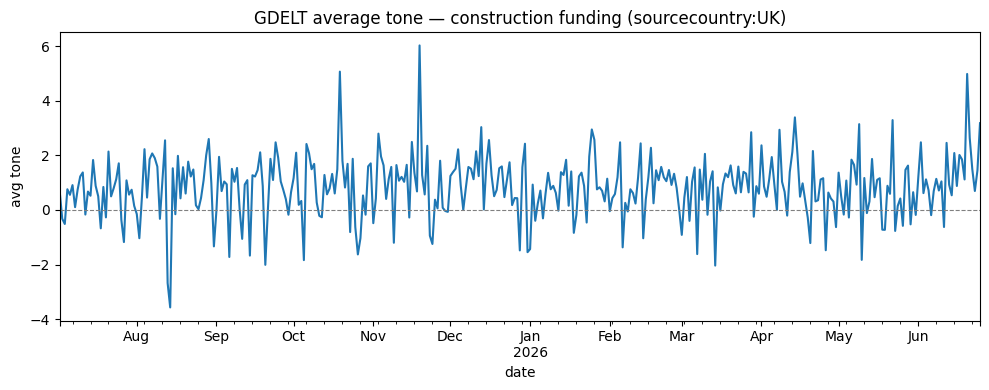

In [18]:
# ---------------------------------------------------------------------------
# Example: tone timeline for "construction" AND "funding" coverage (UK media)
# keyword= means AND (both words must appear). Use phrase= ONLY for an exact
# adjacent phrase like "construction funding", which is far rarer (often 0 hits).
# ---------------------------------------------------------------------------
SEARCH_TERMS = "construction funding"     # space = AND -> both words required
SOURCE_COUNTRY = "UK"

q = build_query(keyword=SEARCH_TERMS, sourcecountry=SOURCE_COUNTRY)
print("Query:", q)

tone = timeline_tone(q, timespan="1y")
print(f"Tone points: {len(tone)}")
if not tone.empty:
    print(tone.tail().to_string(index=False))
    print(f"\nAverage tone over period: {tone['tone'].mean():.2f} (negative = unfavourable)")
    ax = tone.plot(x="date", y="tone", figsize=(10, 4), legend=False,
                   title=f'GDELT average tone — {SEARCH_TERMS} (sourcecountry:{SOURCE_COUNTRY})')
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_ylabel("avg tone")
    plt.tight_layout()
    plt.show()

# Hybrid route — BigQuery (full history · geolocated · no rate limits)

The cells above use the **DOC API** (best when you need *exact free-text* keyword matching).
The cells below reproduce the tone/region analytics via **BigQuery GKG** — **no rate limits**,
full history (2015→now), and the **real `V2Locations`** geography. Use whichever fits the
question; together they're the hybrid.

### One-time setup
1. Create / pick a **GCP project** with **billing enabled**, and enable the **BigQuery API**.
2. Authenticate (pick one):
   - *Local / interactive:* `gcloud auth application-default login`
   - *Scheduled weekly pipeline:* create a **service account** + JSON key, then
     `export GOOGLE_APPLICATION_CREDENTIALS=/path/key.json`
3. Install libs: `pip install google-cloud-bigquery db-dtypes pandas matplotlib`
4. Set `PROJECT` in the next cell.

### Cost safety (important)
- We query the **partitioned** table `gdelt-bq.gdeltv2.gkg_partitioned` and filter
  `_PARTITIONTIME` so only the relevant days are scanned (the unpartitioned `gkg` is **3.6 TB** —
  one careless query can blow the free tier).
- Every query runs a **dry run first** via `bq_query()`, printing the GB it *will* scan and
  **aborting if it exceeds `max_gb`** before anything is billed. Free tier = **1 TB/month**.

### Matching note
The theme filter approximates "construction" + "funding" via GKG **theme names** (`V2Themes`),
not literal article words — refine `THEME_FILTERS` against `LOOKUP-GKGTHEMES.TXT`. When you
truly need literal words, that's exactly when you fall back to the DOC-API cells above.

> Not run in this notebook — these cells need *your* GCP credentials. The Python logic is
> validated; the dry-run guard protects you from surprise cost on first run.

In [14]:
# --- BigQuery hybrid route: imports + client -------------------------------
# Run once:  pip install google-cloud-bigquery db-dtypes pandas matplotlib
import datetime as dt
import re
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT = "lloyds-gdelt"   # <-- set your GCP project (billing must be enabled)

try:
    client = bigquery.Client(project=PROJECT)
    print("BigQuery client ready for project:", client.project)
except Exception as e:
    client = None
    print("BigQuery client NOT ready — finish the setup steps in the markdown above.\n ",
          type(e).__name__, ":", e)

BigQuery client ready for project: lloyds-gdelt


In [15]:
# --- Config + helpers ------------------------------------------------------
GKG = "`gdelt-bq.gdeltv2.gkg_partitioned`"   # partitioned table = cheap date pruning

# Run window. For a weekly job this is "the last 7 days".
END_D   = dt.date.today()
START_D = END_D - dt.timedelta(days=7)

# Theme approximation of your free-text intent ("construction" + "funding").
# Each inner list = OR (a theme NAME contains any token); the groups are AND-ed.
# Refine these tokens against LOOKUP-GKGTHEMES.TXT, then spot-check matching URLs.
THEME_FILTERS = [
    ["CONSTRUCTION", "INFRASTRUCTURE", "BUILDING"],
    ["FUND", "SUBSID", "FINANC", "INVEST", "GRANT"],
]

# UK city -> region rollup (extend freely). Unmapped cities -> "Other / unmapped".
CITY_TO_REGION = {
    "London": "London",
    "Birmingham": "West Midlands", "Coventry": "West Midlands", "Wolverhampton": "West Midlands",
    "Leicester": "East Midlands", "Nottingham": "East Midlands", "Derby": "East Midlands",
    "Manchester": "North West", "Liverpool": "North West", "Preston": "North West", "Bolton": "North West",
    "Leeds": "Yorkshire", "Sheffield": "Yorkshire", "Bradford": "Yorkshire", "York": "Yorkshire", "Hull": "Yorkshire",
    "Newcastle": "North East", "Sunderland": "North East", "Durham": "North East", "Middlesbrough": "North East",
    "Bristol": "South West", "Plymouth": "South West", "Exeter": "South West", "Bath": "South West", "Gloucester": "South West",
    "Southampton": "South East", "Portsmouth": "South East", "Brighton": "South East", "Oxford": "South East", "Reading": "South East",
    "Norwich": "East of England", "Cambridge": "East of England", "Ipswich": "East of England", "Peterborough": "East of England",
    "Glasgow": "Scotland", "Edinburgh": "Scotland", "Aberdeen": "Scotland", "Dundee": "Scotland",
    "Cardiff": "Wales", "Swansea": "Wales", "Newport": "Wales",
    "Belfast": "Northern Ireland", "Derry": "Northern Ireland",
}


def theme_where(groups, col="V2Themes"):
    """Build a sanitized '(.. OR ..) AND (.. OR ..)' theme filter from token groups."""
    parts = []
    for grp in groups:
        ors = []
        for tok in grp:
            assert re.fullmatch(r"[A-Z0-9_]+", tok), f"bad theme token: {tok!r}"
            ors.append(f"{col} LIKE '%{tok}%'")
        parts.append("(" + " OR ".join(ors) + ")")
    return " AND ".join(parts) if parts else "TRUE"


def date_params(start_d, end_d):
    """Partition + DATE-column params for cost-pruned, inclusive date filtering."""
    return [
        bigquery.ScalarQueryParameter("pstart", "TIMESTAMP", f"{start_d} 00:00:00"),
        bigquery.ScalarQueryParameter("pend", "TIMESTAMP",
                                      f"{end_d + dt.timedelta(days=1)} 00:00:00"),
        bigquery.ScalarQueryParameter("dstart", "INT64",
                                      int(start_d.strftime('%Y%m%d')) * 1000000),
        bigquery.ScalarQueryParameter("dend", "INT64",
                                      int(end_d.strftime('%Y%m%d')) * 1000000 + 235959),
    ]


def bq_query(sql, params=None, max_gb=5.0, run=True):
    """Dry-run first (print GB scanned), abort if > max_gb, else run -> DataFrame.

    The dry run is free and is your cost seatbelt: it tells you how many GB the
    query WILL scan before a single byte is billed. max_gb is a hard ceiling.
    """
    if client is None:
        raise RuntimeError("BigQuery client not initialised — see the setup cell.")
    cfg = bigquery.QueryJobConfig(query_parameters=params or [],
                                  dry_run=True, use_query_cache=False)
    gb = client.query(sql, job_config=cfg).total_bytes_processed / 1e9
    print(f"Dry run: ~{gb:.2f} GB will be scanned (free tier = 1000 GB/month).")
    if gb > max_gb:
        raise RuntimeError(f"Query would scan {gb:.2f} GB > max_gb={max_gb}. "
                           "Tighten the date range/filters, or raise max_gb if intended.")
    if not run:
        return None
    cfg = bigquery.QueryJobConfig(query_parameters=params or [])
    return client.query(sql, job_config=cfg).to_dataframe()

Dry run: ~3.60 GB will be scanned (free tier = 1000 GB/month).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


       day  articles  avg_tone
2026-06-18      1200 -1.365940
2026-06-19      1274 -3.153032
2026-06-20      1310 -3.541987
2026-06-21       602 -2.681771
2026-06-22       921 -1.554040
2026-06-23      1256 -1.639841
2026-06-24       975 -1.744780
2026-06-25       711 -1.598133


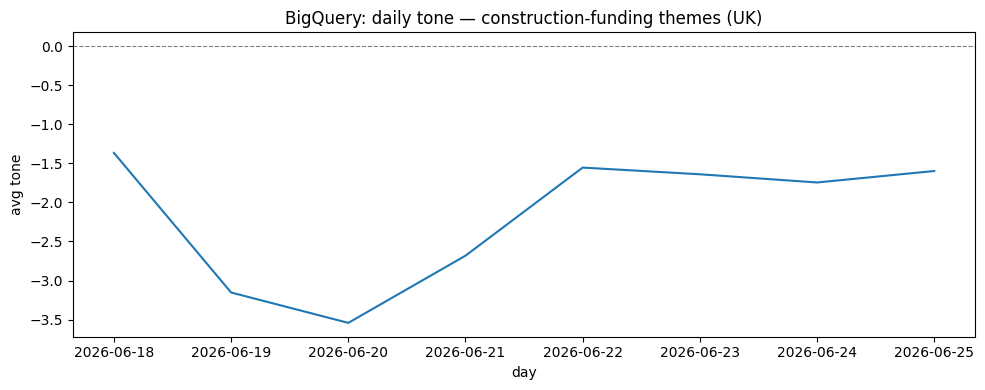

In [ ]:
# --- Query A: daily tone + volume (the timelinetone-equivalent) -------------
sql_timeline = f"""
SELECT
  PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS day,
  COUNT(*) AS articles,
  AVG(SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)) AS avg_tone
FROM {GKG}
WHERE _PARTITIONTIME >= TIMESTAMP(@pstart) AND _PARTITIONTIME < TIMESTAMP(@pend)
  AND DATE >= @dstart AND DATE <= @dend
  AND V2Locations LIKE '%#UK#%'             -- coverage that mentions the UK
  AND {theme_where(THEME_FILTERS)}
GROUP BY day
ORDER BY day
"""

tl = bq_query(sql_timeline, params=date_params(START_D, END_D), max_gb=5.0)
print(tl.to_string(index=False))
if not tl.empty:
    ax = tl.plot(x="day", y="avg_tone", legend=False, figsize=(10, 4),
                 title= f"BigQuery: daily tone — {SEARCH_TERMS} themes (UK)")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_ylabel("avg tone")
    plt.tight_layout(); plt.show()

Dry run: ~3.60 GB will be scanned (free tier = 1000 GB/month).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


UK regions the construction-funding coverage is about:

                  mentions  avg_tone
region                              
Other / unmapped     22365    -4.249
London                6270    -2.851
East Midlands         1246    -4.833
North West            1027    -1.947
Northern Ireland       664    -4.562
Scotland               397     -1.25
East of England        165    -0.969
South West              93    -2.437
South East              34    -1.188
North East              17     0.805
Wales                    8    -2.742


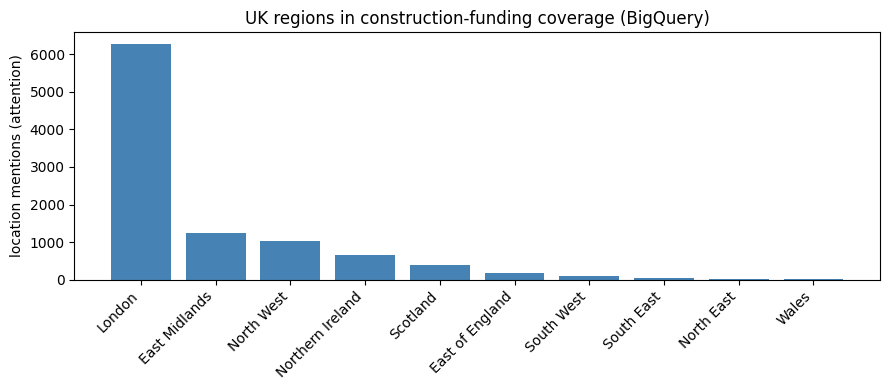

In [ ]:
# --- Query B: which UK locations the coverage is ABOUT -> roll up to regions -
# Unnest V2Locations, keep UK city-level mentions (Type >= 3), aggregate tone.
sql_places = f"""
SELECT
  SPLIT(loc, '#')[SAFE_OFFSET(1)] AS place,
  COUNT(*) AS mentions,
  AVG(SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64)) AS avg_tone
FROM {GKG}, UNNEST(SPLIT(V2Locations, ';')) AS loc
WHERE _PARTITIONTIME >= TIMESTAMP(@pstart) AND _PARTITIONTIME < TIMESTAMP(@pend)
  AND DATE >= @dstart AND DATE <= @dend
  AND {theme_where(THEME_FILTERS)}
  AND SPLIT(loc, '#')[SAFE_OFFSET(2)] = 'UK'                    -- UK locations only
  AND SAFE_CAST(SPLIT(loc, '#')[SAFE_OFFSET(0)] AS INT64) >= 3  -- city/ADM1, not country
GROUP BY place
ORDER BY mentions DESC
"""

places = bq_query(sql_places, params=date_params(START_D, END_D), max_gb=5.0)

# Map each geolocated city (first token of the full name) -> UK region, in pandas.
places["city"] = places["place"].str.split(",").str[0].str.strip()
places["region"] = places["city"].map(CITY_TO_REGION).fillna("Other / unmapped")

# Coverage-weighted average tone + total attention (mentions) per region.
# (version-portable: named .agg instead of groupby.apply)
places["_wt"] = places["avg_tone"] * places["mentions"]
region = places.groupby("region").agg(mentions=("mentions", "sum"), _wt=("_wt", "sum"))
region["avg_tone"] = (region["_wt"] / region["mentions"]).round(3)
region["mentions"] = region["mentions"].astype(int)
region = region.drop(columns="_wt").sort_values("mentions", ascending=False)

if not region.empty:
    print(f"UK regions the {SEARCH_TERMS} coverage is about:\n")
    print(region.to_string())
    sub = region.drop(index="Other / unmapped", errors="ignore")
    fig, ax = plt.subplots(figsize=(9, 4))                      # explicit ax.bar = robust
    ax.bar(sub.index.astype(str), sub["mentions"], color="steelblue")
    ax.set_title(f"UK regions in {SEARCH_TERMS} coverage (BigQuery)")
    ax.set_ylabel("location mentions (attention)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

# Sector funding-sentiment — comparable across sectors (z-score)

**Goal:** each week, surface the SIC sectors whose **funding/lending sentiment is improving**, to
flag where SME borrowing demand may be rising (a sector-level feature you join to each SME by SIC).

**Why not just rank raw average tone?** Sectors have different baseline coverage tone *and* very
different article volumes, so a raw cross-sector ranking mostly reflects "which sectors are
habitually written about positively" + small-sample noise. Instead we **z-score each sector
against its own ~1-year history**:

> `z = (latest-week tone − sector's baseline mean) / sector's baseline std`

A high `z` means "unusually positive **for this sector**", which *is* comparable across sectors.
Rank by `z` = **most-improved funding sentiment this week**. We also require a minimum sample so
tiny sectors don't top the list by luck.

- **BigQuery** — one query sweeps all sectors with **true article counts** + full baseline; the heavy query, guarded by the dry-run cost check.

⚠️ These are **sector-level** signals — GDELT can't see individual SMEs, so this contextualises *which sectors* are heating up, not individual firms.

Loaded 297 rows from cache 'sector_weekly_cache_26w.parquet' (0 GB scanned). Set USE_CACHE=False to pull fresh data.

BigQuery — sector funding sentiment, most improved this week (z-score):

               sector latest_week  latest_articles  latest_tone  baseline_tone     z
   Financial services  2026-06-21            12260        -0.80          -1.31  1.68
  Information & comms  2026-06-21             5392        -0.90          -1.50  1.55
Transport & logistics  2026-06-21             4505        -0.99          -1.74  1.50
         Construction  2026-06-21             3120        -0.97          -1.55  1.12
          Real estate  2026-06-21             2139        -0.24          -0.64  1.06
        Manufacturing  2026-06-21              995         0.19          -0.31  1.05
          Agriculture  2026-06-21             4185        -0.78          -1.15  0.92
 Health & social care  2026-06-21             6138        -1.31          -1.62  0.73
   Energy & utilities  2026-06-21           

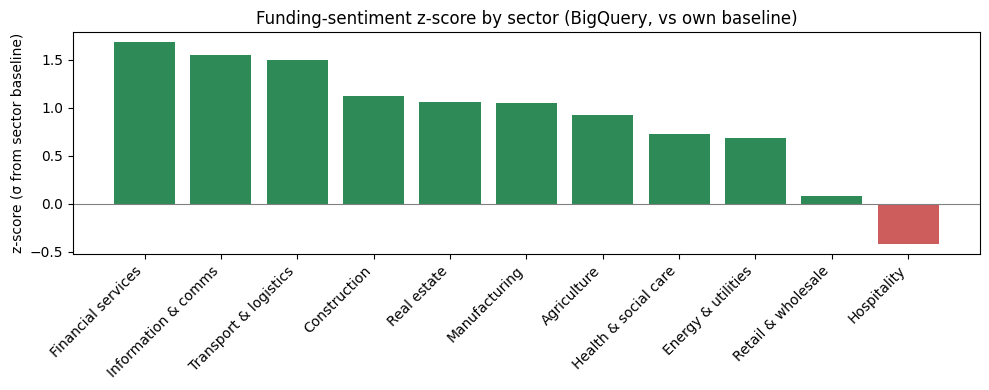

In [ ]:
# ===========================================================================
# BigQuery version — ALL sectors in one query, true article counts, baseline z
# ===========================================================================
# --- dev / cost controls (protect your 1 TB/month free tier) ---------------
USE_CACHE = True    # if a cache file exists, load it (0 GB) instead of querying
DEV_MODE  = False    # True -> tiny 4-week window for a cheap real-data smoke test

# Workflow: leave USE_CACHE=True to iterate the z-score/plot for free on cached data.
# Set USE_CACHE=False once to pull fresh data (it overwrites the cache).
# Use DEV_MODE=True for a ~13 GB smoke test; False = full ~85 GB / 26-week run.
# ---------------------------------------------------------------------------
import os

# A row can match several sectors (sectors overlap) — that's expected.
# Sector matching is on V2Themes theme-NAMES (approximate; refine vs LOOKUP-GKGTHEMES).
SECTOR_PATTERNS = {                         # sector -> regex alternation (lowercase)
    "Construction":          "construction|infrastructure|building",
    "Manufacturing":         "manufactur|industrial",
    "Retail & wholesale":    "retail|wholesale|consumer goods",
    "Transport & logistics": "transport|logistic|freight|shipping|aviation",
    "Hospitality":           "hospitality|tourism|restaurant|hotel",
    "Real estate":           "real estate|property|housing",
    "Information & comms":    "telecom|software|information technology|media",
    "Financial services":    "bank|financ|insurance|fintech",
    "Health & social care":  "health|social care|hospital|pharma",
    "Energy & utilities":    "energy|electricity|utilit|renewable",
    "Agriculture":           "agricultur|farming|forestry|fishing",
}
FUNDING_PAT = "fund|investment|financ|lend|loan|subsidy|grant|capital"


def _safe_pat(p):                           # allow only word chars, spaces, '|'
    assert re.fullmatch(r"[a-z0-9 |]+", p), f"unsafe pattern: {p!r}"
    return p


_sector_cte = " UNION ALL ".join(
    f"SELECT '{name}' AS sector, r'{_safe_pat(pat)}' AS pat"
    for name, pat in SECTOR_PATTERNS.items())

# Baseline length drives scan cost: ~3.3 GB/week of GKG text columns.
#   4 wk (dev) ≈ 13 GB  |  26 wk (~6 mo) ≈ 85 GB  |  53 wk (~1 yr) ≈ 174 GB.
BASE_WEEKS = 4 if DEV_MODE else 26
bq_start = END_D - dt.timedelta(weeks=BASE_WEEKS)
CACHE_FILE = f"sector_weekly_cache_{BASE_WEEKS}w.parquet"   # window-specific cache

sql_sector = f"""
WITH sectors AS ( {_sector_cte} ),
matched AS (
  SELECT
    s.sector,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND g.V2Locations LIKE '%#UK#%'
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, week, COUNT(*) AS articles, AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, week
ORDER BY sector, week
"""

# Free re-runs: load the cache if present; otherwise query (dry-run guarded) + cache.
if USE_CACHE and os.path.exists(CACHE_FILE):
    weekly = pd.read_parquet(CACHE_FILE)
    print(f"Loaded {len(weekly)} rows from cache '{CACHE_FILE}' (0 GB scanned). "
          "Set USE_CACHE=False to pull fresh data.")
else:
    weekly = bq_query(sql_sector, params=date_params(bq_start, END_D), max_gb=100.0)
    weekly.to_parquet(CACHE_FILE)
    print(f"Queried BigQuery and cached {len(weekly)} rows -> '{CACHE_FILE}'.")

MIN_ARTICLES, MIN_WEEKS = 25, 12           # min-article floor + enough baseline weeks
out = []
for sec, d in weekly.groupby("sector"):
    d = d.sort_values("week")
    latest, base = d.iloc[-1], d.iloc[:-1]      # latest week vs its own prior weeks
    sd = base["avg_tone"].std(ddof=0)
    ok = len(base) >= MIN_WEEKS and sd and sd > 0 and latest["articles"] >= MIN_ARTICLES
    z = (latest["avg_tone"] - base["avg_tone"].mean()) / sd if ok else float("nan")
    out.append({"sector": sec, "latest_week": latest["week"],
                "latest_articles": int(latest["articles"]),
                "latest_tone": round(float(latest["avg_tone"]), 2),
                "baseline_tone": round(float(base["avg_tone"].mean()), 2) if len(base) else float("nan"),
                "z": round(float(z), 2) if z == z else float("nan")})
ranked_bq = (pd.DataFrame(out).sort_values("z", ascending=False, na_position="last")
             .reset_index(drop=True))
print("\nBigQuery — sector funding sentiment, most improved this week (z-score):\n")
print(ranked_bq.to_string(index=False))

r = ranked_bq.dropna(subset=["z"])
if not r.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(r["sector"].astype(str), r["z"],
           color=["seagreen" if v >= 0 else "indianred" for v in r["z"]])
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_title("Funding-sentiment z-score by sector (BigQuery, vs own baseline)")
    ax.set_ylabel("z-score (σ from sector baseline)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()